# XGBoost

#### Imports

In [43]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.xgb_experiment import XGBExperiment
from src.utils import evaluate_model, save_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experimento 1: Conjunto com todas as Features

In [44]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### XGboost - Default

In [45]:
import xgboost as xgb

xgboost_exp1 = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost_exp1.fit(X_train_exp1, y_train_exp1)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== Métricas xgb_def_exp1  ===
    Acurácia: 0.7770
    Precisão: 0.7484
    Recall:   0.7509
    F1-Score: 0.7496
    MCC:      0.4992
    AUC:      0.8419


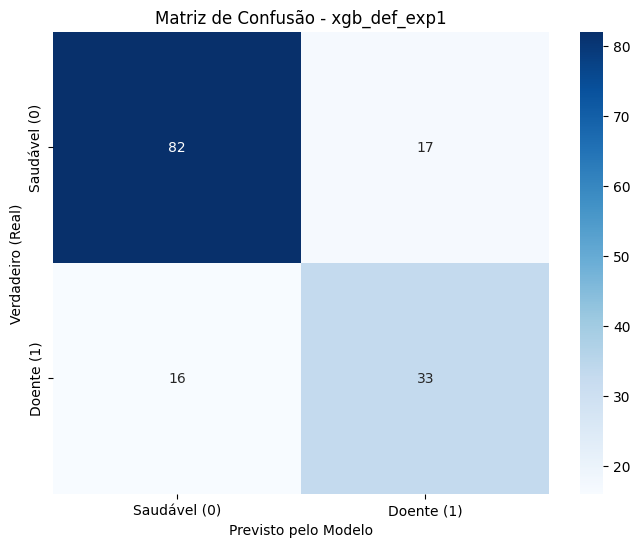

In [46]:
# Avaliar modelo
y_pred_def_exp1 = xgboost_exp1.predict(X_test_exp1)
y_prob_def_exp1 = xgboost_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'xgb_def_exp1', caminho)

### XGBoost - Melhorado

In [47]:
# Criar o experimento
experimento_1 = XGBExperiment(X_train_exp1, y_train_exp1, 'xgb_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_xgb = experimento_1.best_model

[I 2026-08-18 19:25:50,575] A new study created in memory with name: no-name-137fe367-83a4-4a9e-abdc-16d5d9e3e6c4


Iniciando otimização do cenário xgb_otz_exp1.


Best trial: 0. Best value: 0.8097:   4%|▍         | 2/50 [00:00<00:08,  5.44it/s]

[I 2026-08-18 19:25:50,795] Trial 0 finished with value: 0.8097001110699741 and parameters: {'n_estimators': 228, 'max_depth': 6, 'learning_rate': 0.03317133890194856, 'subsample': 0.7155176165059071, 'colsample_bytree': 0.7137724227522277, 'gamma': 4.586933001541285}. Best is trial 0 with value: 0.8097001110699741.
[I 2026-08-18 19:25:50,952] Trial 1 finished with value: 0.7827964951252623 and parameters: {'n_estimators': 101, 'max_depth': 5, 'learning_rate': 0.14239123130249937, 'subsample': 0.9223098144933601, 'colsample_bytree': 0.9280544855653378, 'gamma': 0.45791902831769093}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:   6%|▌         | 3/50 [00:00<00:08,  5.83it/s]

[I 2026-08-18 19:25:51,109] Trial 2 finished with value: 0.773664075033938 and parameters: {'n_estimators': 98, 'max_depth': 6, 'learning_rate': 0.04202714607116188, 'subsample': 0.5535522158256085, 'colsample_bytree': 0.5125996065175277, 'gamma': 1.0445919124085945}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:  10%|█         | 5/50 [00:01<00:09,  4.81it/s]

[I 2026-08-18 19:25:51,429] Trial 3 finished with value: 0.7873627051709243 and parameters: {'n_estimators': 251, 'max_depth': 6, 'learning_rate': 0.013375324482622932, 'subsample': 0.666051070944794, 'colsample_bytree': 0.9706892524613693, 'gamma': 2.7058409870846396}. Best is trial 0 with value: 0.8097001110699741.
[I 2026-08-18 19:25:51,598] Trial 4 finished with value: 0.8053807231889424 and parameters: {'n_estimators': 104, 'max_depth': 4, 'learning_rate': 0.02916479838544191, 'subsample': 0.8077312488240936, 'colsample_bytree': 0.8582394130397613, 'gamma': 2.872882621327888}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:  14%|█▍        | 7/50 [00:01<00:07,  5.71it/s]

[I 2026-08-18 19:25:51,779] Trial 5 finished with value: 0.7918672096754289 and parameters: {'n_estimators': 152, 'max_depth': 6, 'learning_rate': 0.026872302300730178, 'subsample': 0.7153272075540413, 'colsample_bytree': 0.78988310268187, 'gamma': 2.135787087255471}. Best is trial 0 with value: 0.8097001110699741.
[I 2026-08-18 19:25:51,905] Trial 6 finished with value: 0.7917437985931137 and parameters: {'n_estimators': 62, 'max_depth': 5, 'learning_rate': 0.07560834768977145, 'subsample': 0.9408522465479964, 'colsample_bytree': 0.9330514232957481, 'gamma': 1.014481883400663}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:  18%|█▊        | 9/50 [00:01<00:06,  5.89it/s]

[I 2026-08-18 19:25:52,090] Trial 7 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 136, 'max_depth': 6, 'learning_rate': 0.05614018891453184, 'subsample': 0.6188038893339842, 'colsample_bytree': 0.5929455880772192, 'gamma': 1.5067098040047522}. Best is trial 0 with value: 0.8097001110699741.
[I 2026-08-18 19:25:52,242] Trial 8 finished with value: 0.7962483030976181 and parameters: {'n_estimators': 104, 'max_depth': 3, 'learning_rate': 0.018230987164952337, 'subsample': 0.7400435196818442, 'colsample_bytree': 0.581287732040884, 'gamma': 1.1621716533589503}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:  20%|██        | 10/50 [00:01<00:06,  6.37it/s]

[I 2026-08-18 19:25:52,370] Trial 9 finished with value: 0.7737874861162531 and parameters: {'n_estimators': 88, 'max_depth': 5, 'learning_rate': 0.24815744981611926, 'subsample': 0.6663074525831154, 'colsample_bytree': 0.7567348087599486, 'gamma': 0.61207991700088}. Best is trial 0 with value: 0.8097001110699741.


[I 2026-08-18 19:25:52,563] Trial 10 finished with value: 0.7962483030976181 and parameters: {'n_estimators': 223, 'max_depth': 9, 'learning_rate': 0.11252093873250023, 'subsample': 0.8306679668840529, 'colsample_bytree': 0.6762777264186927, 'gamma': 4.879300140505886}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 0. Best value: 0.8097:  24%|██▍       | 12/50 [00:02<00:06,  5.82it/s]

[I 2026-08-18 19:25:52,743] Trial 11 finished with value: 0.800691102060965 and parameters: {'n_estimators': 195, 'max_depth': 3, 'learning_rate': 0.028921656403244716, 'subsample': 0.827104133903349, 'colsample_bytree': 0.8579782193348505, 'gamma': 4.194026853588564}. Best is trial 0 with value: 0.8097001110699741.


Best trial: 12. Best value: 0.809824:  26%|██▌       | 13/50 [00:02<00:07,  5.06it/s]

[I 2026-08-18 19:25:53,001] Trial 12 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 271, 'max_depth': 8, 'learning_rate': 0.011099911267246543, 'subsample': 0.8239262067556531, 'colsample_bytree': 0.8429970968767482, 'gamma': 3.4633727477604443}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  28%|██▊       | 14/50 [00:02<00:07,  4.59it/s]

[I 2026-08-18 19:25:53,263] Trial 13 finished with value: 0.8052573121066272 and parameters: {'n_estimators': 295, 'max_depth': 8, 'learning_rate': 0.010154838321150715, 'subsample': 0.5074931585525349, 'colsample_bytree': 0.6942791153844594, 'gamma': 3.743681353106332}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  30%|███       | 15/50 [00:03<00:09,  3.83it/s]

[I 2026-08-18 19:25:53,626] Trial 14 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 278, 'max_depth': 8, 'learning_rate': 0.018340143452936455, 'subsample': 0.8802208761005181, 'colsample_bytree': 0.8280946667563924, 'gamma': 3.646567652929743}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  32%|███▏      | 16/50 [00:03<00:10,  3.30it/s]

[I 2026-08-18 19:25:54,027] Trial 15 finished with value: 0.7961865975564605 and parameters: {'n_estimators': 231, 'max_depth': 10, 'learning_rate': 0.015841244637484306, 'subsample': 0.77866945333267, 'colsample_bytree': 0.6916559263393876, 'gamma': 4.998079596330599}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  34%|███▍      | 17/50 [00:03<00:10,  3.30it/s]

[I 2026-08-18 19:25:54,331] Trial 16 finished with value: 0.800691102060965 and parameters: {'n_estimators': 199, 'max_depth': 8, 'learning_rate': 0.03955838448371474, 'subsample': 0.9734409799953502, 'colsample_bytree': 0.7384999763168647, 'gamma': 4.265440562261475}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  38%|███▊      | 19/50 [00:04<00:08,  3.62it/s]

[I 2026-08-18 19:25:54,692] Trial 17 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 263, 'max_depth': 7, 'learning_rate': 0.010503004617244193, 'subsample': 0.8666126834844783, 'colsample_bytree': 0.6279448908857621, 'gamma': 3.2755348109181956}. Best is trial 12 with value: 0.8098235221522893.
[I 2026-08-18 19:25:54,868] Trial 18 finished with value: 0.7961248920153029 and parameters: {'n_estimators': 219, 'max_depth': 10, 'learning_rate': 0.08203301929172682, 'subsample': 0.6892059988219468, 'colsample_bytree': 0.8140456502116749, 'gamma': 4.298949420936281}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  40%|████      | 20/50 [00:04<00:08,  3.54it/s]

[I 2026-08-18 19:25:55,164] Trial 19 finished with value: 0.7918672096754289 and parameters: {'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.021477333342778872, 'subsample': 0.7720636022721854, 'colsample_bytree': 0.8875556154330349, 'gamma': 2.055226806188774}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  42%|████▏     | 21/50 [00:04<00:07,  3.79it/s]

[I 2026-08-18 19:25:55,383] Trial 20 finished with value: 0.7646550660249289 and parameters: {'n_estimators': 248, 'max_depth': 9, 'learning_rate': 0.29153687117905175, 'subsample': 0.5932006582871665, 'colsample_bytree': 0.7545891150881915, 'gamma': 3.228821232291804}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  46%|████▌     | 23/50 [00:05<00:05,  4.62it/s]

[I 2026-08-18 19:25:55,576] Trial 21 finished with value: 0.7963717141799332 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.032379700836262515, 'subsample': 0.809155679769475, 'colsample_bytree': 0.9066962902687878, 'gamma': 2.731908718733983}. Best is trial 12 with value: 0.8098235221522893.
[I 2026-08-18 19:25:55,731] Trial 22 finished with value: 0.7781685795384425 and parameters: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.05302379229729632, 'subsample': 0.8652979741478694, 'colsample_bytree': 0.9925772109315325, 'gamma': 3.1643121477542526}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  46%|████▌     | 23/50 [00:05<00:05,  4.62it/s]

[I 2026-08-18 19:25:55,833] Trial 23 finished with value: 0.7961248920153029 and parameters: {'n_estimators': 58, 'max_depth': 4, 'learning_rate': 0.02359380664789488, 'subsample': 0.7478377449381112, 'colsample_bytree': 0.853865447258394, 'gamma': 3.7890644040338883}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  50%|█████     | 25/50 [00:05<00:04,  5.22it/s]

[I 2026-08-18 19:25:56,057] Trial 24 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 197, 'max_depth': 7, 'learning_rate': 0.01355891523854811, 'subsample': 0.7994201677806114, 'colsample_bytree': 0.7867937564769085, 'gamma': 4.528052716736152}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  52%|█████▏    | 26/50 [00:05<00:05,  4.15it/s]

[I 2026-08-18 19:25:56,447] Trial 25 finished with value: 0.7827964951252623 and parameters: {'n_estimators': 274, 'max_depth': 9, 'learning_rate': 0.03717281719384648, 'subsample': 0.7051888154249669, 'colsample_bytree': 0.7306486253697339, 'gamma': 2.424806293701679}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  54%|█████▍    | 27/50 [00:06<00:05,  3.90it/s]

[I 2026-08-18 19:25:56,748] Trial 26 finished with value: 0.8097618166111317 and parameters: {'n_estimators': 173, 'max_depth': 5, 'learning_rate': 0.05604013685957363, 'subsample': 0.9196257161243562, 'colsample_bytree': 0.867501406658533, 'gamma': 2.9651727209841}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  56%|█████▌    | 28/50 [00:06<00:05,  4.18it/s]

[I 2026-08-18 19:25:56,939] Trial 27 finished with value: 0.800691102060965 and parameters: {'n_estimators': 175, 'max_depth': 7, 'learning_rate': 0.05354316070551415, 'subsample': 0.9998815790559706, 'colsample_bytree': 0.6490084030006669, 'gamma': 3.917265144655678}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  58%|█████▊    | 29/50 [00:06<00:05,  3.58it/s]

[I 2026-08-18 19:25:57,322] Trial 28 finished with value: 0.7872392940886092 and parameters: {'n_estimators': 239, 'max_depth': 5, 'learning_rate': 0.0866558731137259, 'subsample': 0.906245125278793, 'colsample_bytree': 0.8095389229385195, 'gamma': 0.013967426151614504}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  60%|██████    | 30/50 [00:06<00:05,  3.76it/s]

[I 2026-08-18 19:25:57,553] Trial 29 finished with value: 0.791682093051956 and parameters: {'n_estimators': 210, 'max_depth': 8, 'learning_rate': 0.1624106891766161, 'subsample': 0.9114040556607067, 'colsample_bytree': 0.947205555894141, 'gamma': 3.4498364920071554}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  62%|██████▏   | 31/50 [00:07<00:07,  2.63it/s]

[I 2026-08-18 19:25:58,202] Trial 30 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 152, 'max_depth': 5, 'learning_rate': 0.15398409512112327, 'subsample': 0.9457477056176633, 'colsample_bytree': 0.8970477784885179, 'gamma': 4.650602408635365}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  64%|██████▍   | 32/50 [00:08<00:09,  1.92it/s]

[I 2026-08-18 19:25:59,070] Trial 31 finished with value: 0.7917437985931137 and parameters: {'n_estimators': 119, 'max_depth': 4, 'learning_rate': 0.046912673099364845, 'subsample': 0.8434740415860655, 'colsample_bytree': 0.8545101905816345, 'gamma': 2.7401289286876027}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  66%|██████▌   | 33/50 [00:09<00:09,  1.79it/s]

[I 2026-08-18 19:25:59,715] Trial 32 finished with value: 0.8008762186844378 and parameters: {'n_estimators': 172, 'max_depth': 5, 'learning_rate': 0.06365903523970289, 'subsample': 0.7789020989086398, 'colsample_bytree': 0.8615273282961514, 'gamma': 2.9447809398940135}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  68%|██████▊   | 34/50 [00:11<00:18,  1.13s/it]

[I 2026-08-18 19:26:02,210] Trial 33 finished with value: 0.7918055041342713 and parameters: {'n_estimators': 261, 'max_depth': 6, 'learning_rate': 0.03472799340259352, 'subsample': 0.8912986879640331, 'colsample_bytree': 0.7796215568049475, 'gamma': 2.28082332391591}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  70%|███████   | 35/50 [00:13<00:18,  1.22s/it]

[I 2026-08-18 19:26:03,649] Trial 34 finished with value: 0.7872392940886092 and parameters: {'n_estimators': 121, 'max_depth': 6, 'learning_rate': 0.026599255671936925, 'subsample': 0.7293428818973721, 'colsample_bytree': 0.9564810836721904, 'gamma': 1.7779271817786462}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  72%|███████▏  | 36/50 [00:13<00:14,  1.06s/it]

[I 2026-08-18 19:26:04,329] Trial 35 finished with value: 0.7917437985931137 and parameters: {'n_estimators': 77, 'max_depth': 3, 'learning_rate': 0.04520539389605154, 'subsample': 0.6427866163107977, 'colsample_bytree': 0.9138488838111324, 'gamma': 2.9876931230743904}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  74%|███████▍  | 37/50 [00:14<00:14,  1.11s/it]

[I 2026-08-18 19:26:05,538] Trial 36 finished with value: 0.7826113785017895 and parameters: {'n_estimators': 161, 'max_depth': 4, 'learning_rate': 0.11137109628130629, 'subsample': 0.9382465929254569, 'colsample_bytree': 0.8312068196731166, 'gamma': 3.4593963208968135}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  76%|███████▌  | 38/50 [00:16<00:14,  1.21s/it]

[I 2026-08-18 19:26:06,998] Trial 37 finished with value: 0.8006293965198075 and parameters: {'n_estimators': 279, 'max_depth': 5, 'learning_rate': 0.06981691272775759, 'subsample': 0.7612731601109641, 'colsample_bytree': 0.5498225855179621, 'gamma': 3.976955408067096}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  78%|███████▊  | 39/50 [00:17<00:12,  1.15s/it]

[I 2026-08-18 19:26:07,995] Trial 38 finished with value: 0.7781685795384425 and parameters: {'n_estimators': 244, 'max_depth': 6, 'learning_rate': 0.021409667867347396, 'subsample': 0.8518515201708761, 'colsample_bytree': 0.8817040641182291, 'gamma': 2.5455997378478044}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  80%|████████  | 40/50 [00:18<00:10,  1.09s/it]

[I 2026-08-18 19:26:08,964] Trial 39 finished with value: 0.800691102060965 and parameters: {'n_estimators': 109, 'max_depth': 5, 'learning_rate': 0.013816829363652626, 'subsample': 0.809817545897648, 'colsample_bytree': 0.7199341250675689, 'gamma': 1.74537529291422}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 12. Best value: 0.809824:  82%|████████▏ | 41/50 [00:19<00:08,  1.03it/s]

[I 2026-08-18 19:26:09,643] Trial 40 finished with value: 0.7872392940886092 and parameters: {'n_estimators': 77, 'max_depth': 6, 'learning_rate': 0.028806776622576837, 'subsample': 0.6741483550697795, 'colsample_bytree': 0.9303083902804445, 'gamma': 2.9589241065728378}. Best is trial 12 with value: 0.8098235221522893.


Best trial: 41. Best value: 0.814328:  84%|████████▍ | 42/50 [00:20<00:08,  1.07s/it]

[I 2026-08-18 19:26:10,957] Trial 41 finished with value: 0.8143280266567938 and parameters: {'n_estimators': 279, 'max_depth': 8, 'learning_rate': 0.018339762705232705, 'subsample': 0.8797738504588349, 'colsample_bytree': 0.8157997680956184, 'gamma': 3.626632459475374}. Best is trial 41 with value: 0.8143280266567938.


Best trial: 42. Best value: 0.818771:  86%|████████▌ | 43/50 [00:21<00:08,  1.23s/it]

[I 2026-08-18 19:26:12,557] Trial 42 finished with value: 0.8187708256201406 and parameters: {'n_estimators': 259, 'max_depth': 8, 'learning_rate': 0.016851446191924416, 'subsample': 0.9629562856447401, 'colsample_bytree': 0.77000261509741, 'gamma': 3.5456833825240666}. Best is trial 42 with value: 0.8187708256201406.


Best trial: 42. Best value: 0.818771:  88%|████████▊ | 44/50 [00:22<00:06,  1.11s/it]

[I 2026-08-18 19:26:13,399] Trial 43 finished with value: 0.8187708256201406 and parameters: {'n_estimators': 262, 'max_depth': 8, 'learning_rate': 0.01699741477113111, 'subsample': 0.968104248942018, 'colsample_bytree': 0.7715447505730895, 'gamma': 3.527940956471754}. Best is trial 42 with value: 0.8187708256201406.


Best trial: 42. Best value: 0.818771:  90%|█████████ | 45/50 [00:24<00:06,  1.34s/it]

[I 2026-08-18 19:26:15,278] Trial 44 finished with value: 0.7961865975564605 and parameters: {'n_estimators': 287, 'max_depth': 9, 'learning_rate': 0.011618711122972072, 'subsample': 0.96648326224877, 'colsample_bytree': 0.7810488757702362, 'gamma': 3.533287109949273}. Best is trial 42 with value: 0.8187708256201406.


Best trial: 42. Best value: 0.818771:  92%|█████████▏| 46/50 [00:26<00:05,  1.40s/it]

[I 2026-08-18 19:26:16,809] Trial 45 finished with value: 0.800691102060965 and parameters: {'n_estimators': 261, 'max_depth': 8, 'learning_rate': 0.016720137553815115, 'subsample': 0.9913604429236118, 'colsample_bytree': 0.7642340395584775, 'gamma': 3.995115552955606}. Best is trial 42 with value: 0.8187708256201406.


Best trial: 42. Best value: 0.818771:  94%|█████████▍| 47/50 [00:27<00:04,  1.50s/it]

[I 2026-08-18 19:26:18,559] Trial 46 finished with value: 0.8051956065654696 and parameters: {'n_estimators': 272, 'max_depth': 8, 'learning_rate': 0.012681437236250436, 'subsample': 0.9258551027975437, 'colsample_bytree': 0.8023370266864404, 'gamma': 3.301555277335798}. Best is trial 42 with value: 0.8187708256201406.


Best trial: 47. Best value: 0.818833:  96%|█████████▌| 48/50 [00:29<00:02,  1.37s/it]

[I 2026-08-18 19:26:19,597] Trial 47 finished with value: 0.8188325311612982 and parameters: {'n_estimators': 256, 'max_depth': 9, 'learning_rate': 0.015102160662688541, 'subsample': 0.9631310967239458, 'colsample_bytree': 0.8278409275773906, 'gamma': 3.6457623436089874}. Best is trial 47 with value: 0.8188325311612982.


Best trial: 48. Best value: 0.823337:  98%|█████████▊| 49/50 [00:29<00:01,  1.18s/it]

[I 2026-08-18 19:26:20,362] Trial 48 finished with value: 0.8233370356658027 and parameters: {'n_estimators': 256, 'max_depth': 9, 'learning_rate': 0.016181088786979263, 'subsample': 0.9627513661184328, 'colsample_bytree': 0.840179354670499, 'gamma': 3.712738638236611}. Best is trial 48 with value: 0.8233370356658027.


Best trial: 48. Best value: 0.823337: 100%|██████████| 50/50 [00:30<00:00,  1.64it/s]


[I 2026-08-18 19:26:21,037] Trial 49 finished with value: 0.8142046155744785 and parameters: {'n_estimators': 235, 'max_depth': 9, 'learning_rate': 0.016027803222409664, 'subsample': 0.964192906556133, 'colsample_bytree': 0.8249095670241768, 'gamma': 4.1721805473033555}. Best is trial 48 with value: 0.8233370356658027.
Melhor pontuação (CV): 0.8233
Melhores parâmetros:
{'n_estimators': 256, 'max_depth': 9, 'learning_rate': 0.016181088786979263, 'subsample': 0.9627513661184328, 'colsample_bytree': 0.840179354670499, 'gamma': 3.712738638236611}


In [48]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===
      feature  importance
  eosinophils      0.1415
  lymphocytes      0.0696
 neutrophilsP      0.0685
    platelets      0.0574
 lymphocytesP      0.0548
    basophils      0.0446
 eosinophilsP      0.0414
          mpv      0.0411
   leukocytes      0.0403
  hematocritP      0.0402
         rdwP      0.0394
   basophilsP      0.0390
redbloodcells      0.0385
   hemoglobin      0.0372
          mch      0.0367
         mchc      0.0365
          age      0.0365
  neutrophils      0.0347
          mcv      0.0346
   monocytesP      0.0341
    monocytes      0.0334
      sex_bin      0.0000


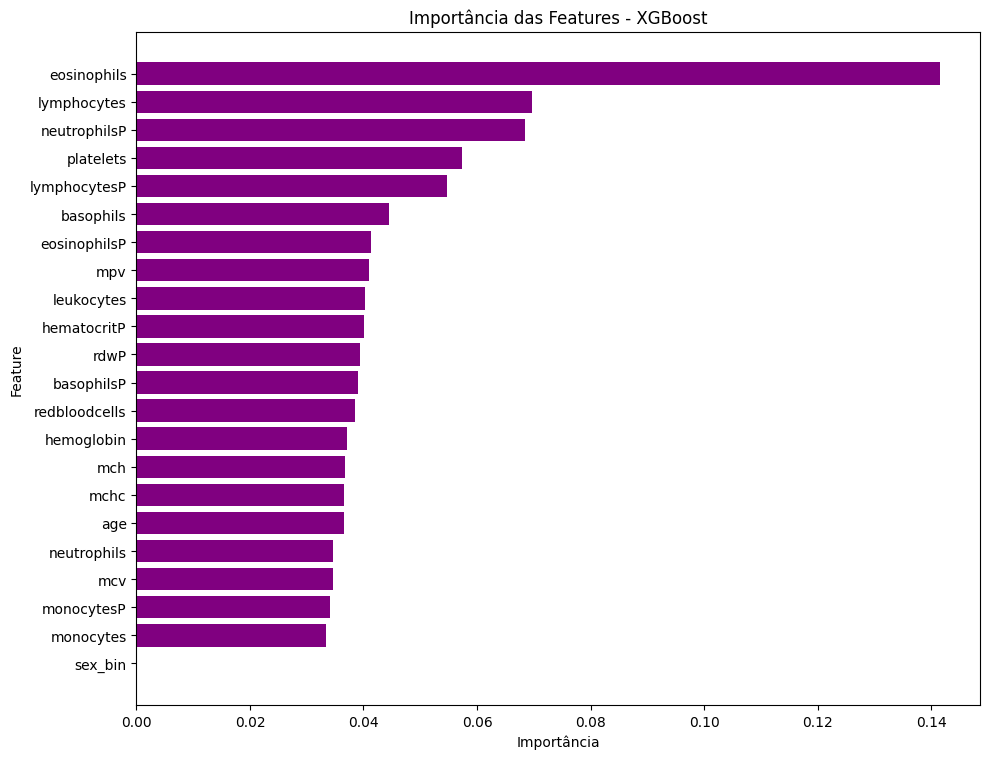

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (XGBoost) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='purple')
plt.title('Importância das Features - XGBoost')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas xgb_otz_exp1  ===
    Acurácia: 0.7568
    Precisão: 0.7251
    Recall:   0.7151
    F1-Score: 0.7194
    MCC:      0.4401
    AUC:      0.8588


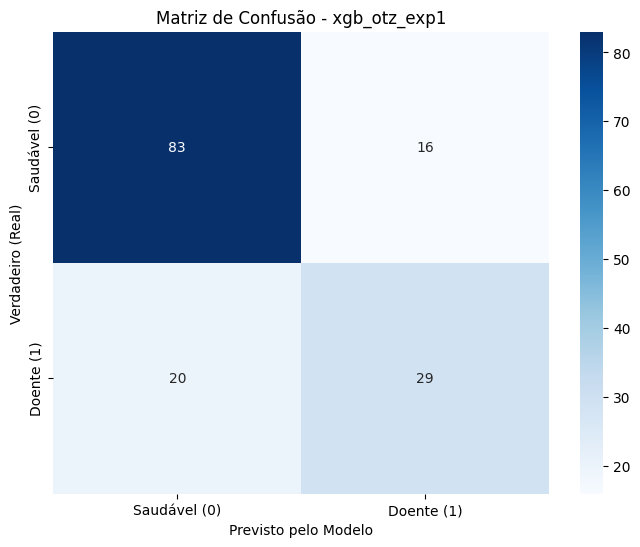

In [50]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'xgb_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [51]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### XGBoost - Default

In [52]:
import xgboost as xgb

xgboost_exp2 = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost_exp2.fit(X_train_exp2, y_train_exp2)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== Métricas xgb_def_exp2  ===
    Acurácia: 0.7162
    Precisão: 0.6759
    Recall:   0.6590
    F1-Score: 0.6647
    MCC:      0.3345
    AUC:      0.7864


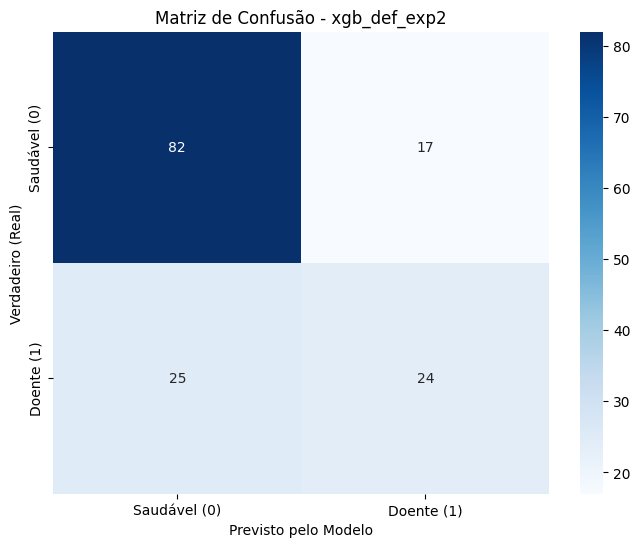

In [53]:
# Avaliar modelo
y_pred_def_exp2 = xgboost_exp2.predict(X_test_exp2)
y_prob_def_exp2 = xgboost_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'xgb_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'xgb_def_exp2', caminho)

### XGBoost - Melhorado

In [54]:
# Criar o experimento
experimento_2 = XGBExperiment(X_train_exp2, y_train_exp2, 'xgb_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:26:25,658] A new study created in memory with name: no-name-ffa68633-9177-45a4-9521-25ebcb66848e


Iniciando otimização do cenário xgb_otz_exp2.


Best trial: 0. Best value: 0.728496:   2%|▏         | 1/50 [00:01<00:59,  1.21s/it]

[I 2026-08-18 19:26:26,861] Trial 0 finished with value: 0.7284956189065778 and parameters: {'n_estimators': 291, 'max_depth': 9, 'learning_rate': 0.08456697799720382, 'subsample': 0.7356702103523705, 'colsample_bytree': 0.6682270129825152, 'gamma': 1.241325160763795}. Best is trial 0 with value: 0.7284956189065778.


Best trial: 0. Best value: 0.728496:   4%|▍         | 2/50 [00:02<01:11,  1.49s/it]

[I 2026-08-18 19:26:28,538] Trial 1 finished with value: 0.7191163766506232 and parameters: {'n_estimators': 157, 'max_depth': 4, 'learning_rate': 0.011515846503354023, 'subsample': 0.926333936802541, 'colsample_bytree': 0.8250802180536478, 'gamma': 2.5021390771580814}. Best is trial 0 with value: 0.7284956189065778.


Best trial: 2. Best value: 0.750895:   6%|▌         | 3/50 [00:03<01:01,  1.31s/it]

[I 2026-08-18 19:26:29,640] Trial 2 finished with value: 0.7508947303467851 and parameters: {'n_estimators': 94, 'max_depth': 8, 'learning_rate': 0.1331627709450035, 'subsample': 0.5622237841001998, 'colsample_bytree': 0.8120130292033159, 'gamma': 4.146420201256588}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:   8%|▊         | 4/50 [00:04<00:52,  1.14s/it]

[I 2026-08-18 19:26:30,526] Trial 3 finished with value: 0.7236825866962854 and parameters: {'n_estimators': 102, 'max_depth': 5, 'learning_rate': 0.29507483881404795, 'subsample': 0.9208019243498144, 'colsample_bytree': 0.5705460054864604, 'gamma': 4.302893579745335}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  10%|█         | 5/50 [00:05<00:41,  1.09it/s]

[I 2026-08-18 19:26:31,052] Trial 4 finished with value: 0.7283722078242626 and parameters: {'n_estimators': 83, 'max_depth': 6, 'learning_rate': 0.011738567659625668, 'subsample': 0.8001686965891859, 'colsample_bytree': 0.5604615137550941, 'gamma': 2.4103675717108985}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  12%|█▏        | 6/50 [00:06<00:36,  1.20it/s]

[I 2026-08-18 19:26:31,728] Trial 5 finished with value: 0.719301493274096 and parameters: {'n_estimators': 115, 'max_depth': 6, 'learning_rate': 0.09751390296649809, 'subsample': 0.7708318449818017, 'colsample_bytree': 0.6081140773012356, 'gamma': 0.40132646783113124}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  14%|█▍        | 7/50 [00:07<00:44,  1.05s/it]

[I 2026-08-18 19:26:33,194] Trial 6 finished with value: 0.7238677033197581 and parameters: {'n_estimators': 289, 'max_depth': 4, 'learning_rate': 0.19225192755460843, 'subsample': 0.6419497525368496, 'colsample_bytree': 0.9104474558862063, 'gamma': 3.1839163866062354}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  16%|█▌        | 8/50 [00:09<00:50,  1.19s/it]

[I 2026-08-18 19:26:34,704] Trial 7 finished with value: 0.7463902258422807 and parameters: {'n_estimators': 136, 'max_depth': 6, 'learning_rate': 0.19149296197815985, 'subsample': 0.6462442315877301, 'colsample_bytree': 0.5492715374748255, 'gamma': 3.2289499427436796}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  18%|█▊        | 9/50 [00:10<00:47,  1.16s/it]

[I 2026-08-18 19:26:35,809] Trial 8 finished with value: 0.7102307787239294 and parameters: {'n_estimators': 145, 'max_depth': 4, 'learning_rate': 0.02221263437852801, 'subsample': 0.7777959447809158, 'colsample_bytree': 0.7706947167749265, 'gamma': 3.5881653717465607}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  20%|██        | 10/50 [00:11<00:46,  1.16s/it]

[I 2026-08-18 19:26:36,939] Trial 9 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 294, 'max_depth': 6, 'learning_rate': 0.02893143469082121, 'subsample': 0.6018712265543906, 'colsample_bytree': 0.6178901649823769, 'gamma': 3.3941261670108362}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  22%|██▏       | 11/50 [00:12<00:45,  1.16s/it]

[I 2026-08-18 19:26:38,114] Trial 10 finished with value: 0.7372578057509563 and parameters: {'n_estimators': 211, 'max_depth': 9, 'learning_rate': 0.053600095092951425, 'subsample': 0.5159596376268968, 'colsample_bytree': 0.9998612389770716, 'gamma': 4.809035277456965}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  24%|██▍       | 12/50 [00:12<00:36,  1.05it/s]

[I 2026-08-18 19:26:38,588] Trial 11 finished with value: 0.7145501666049611 and parameters: {'n_estimators': 63, 'max_depth': 8, 'learning_rate': 0.15148620299956592, 'subsample': 0.5065430650888946, 'colsample_bytree': 0.7106804508773612, 'gamma': 3.8985177129024815}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  26%|██▌       | 13/50 [00:14<00:38,  1.04s/it]

[I 2026-08-18 19:26:39,826] Trial 12 finished with value: 0.7466987535480686 and parameters: {'n_estimators': 188, 'max_depth': 8, 'learning_rate': 0.1532985801011719, 'subsample': 0.6364547879148648, 'colsample_bytree': 0.8352013018993488, 'gamma': 2.4917846449733854}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  28%|██▊       | 14/50 [00:16<00:46,  1.28s/it]

[I 2026-08-18 19:26:41,665] Trial 13 finished with value: 0.7238059977786006 and parameters: {'n_estimators': 202, 'max_depth': 8, 'learning_rate': 0.0864246713659065, 'subsample': 0.5756306718916041, 'colsample_bytree': 0.8445802479567872, 'gamma': 1.899148411515633}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  30%|███       | 15/50 [00:16<00:41,  1.18s/it]

[I 2026-08-18 19:26:42,618] Trial 14 finished with value: 0.7328767123287672 and parameters: {'n_estimators': 196, 'max_depth': 10, 'learning_rate': 0.12505987273330818, 'subsample': 0.6791348862880708, 'colsample_bytree': 0.896956182157371, 'gamma': 4.869225503607379}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  32%|███▏      | 16/50 [00:18<00:43,  1.29s/it]

[I 2026-08-18 19:26:44,147] Trial 15 finished with value: 0.7465753424657534 and parameters: {'n_estimators': 242, 'max_depth': 8, 'learning_rate': 0.053461064056280795, 'subsample': 0.7038561618233853, 'colsample_bytree': 0.7696946863886404, 'gamma': 1.81829272313985}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  34%|███▍      | 17/50 [00:18<00:33,  1.03s/it]

[I 2026-08-18 19:26:44,574] Trial 16 finished with value: 0.7283722078242626 and parameters: {'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.2877135239167593, 'subsample': 0.5718566792717712, 'colsample_bytree': 0.991587097313502, 'gamma': 2.79063540270201}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  36%|███▌      | 18/50 [00:20<00:42,  1.32s/it]

[I 2026-08-18 19:26:46,563] Trial 17 finished with value: 0.7238677033197581 and parameters: {'n_estimators': 246, 'max_depth': 10, 'learning_rate': 0.037315453424561426, 'subsample': 0.8677294029850475, 'colsample_bytree': 0.8312065931772784, 'gamma': 0.8312824742173244}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  38%|███▊      | 19/50 [00:21<00:33,  1.07s/it]

[I 2026-08-18 19:26:47,066] Trial 18 finished with value: 0.705541157595952 and parameters: {'n_estimators': 171, 'max_depth': 7, 'learning_rate': 0.1301417222158796, 'subsample': 0.6220479609647015, 'colsample_bytree': 0.9192294374189373, 'gamma': 4.3120344679320395}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  40%|████      | 20/50 [00:22<00:30,  1.02s/it]

[I 2026-08-18 19:26:47,964] Trial 19 finished with value: 0.7191780821917808 and parameters: {'n_estimators': 119, 'max_depth': 9, 'learning_rate': 0.07017716718616464, 'subsample': 0.9968378349793694, 'colsample_bytree': 0.7094687694399446, 'gamma': 1.8411538087362564}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  42%|████▏     | 21/50 [00:23<00:32,  1.11s/it]

[I 2026-08-18 19:26:49,278] Trial 20 finished with value: 0.7375046279155869 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.19003591793661273, 'subsample': 0.5500713931293165, 'colsample_bytree': 0.7945122253616905, 'gamma': 2.79249425248924}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  44%|████▍     | 22/50 [00:24<00:31,  1.11s/it]

[I 2026-08-18 19:26:50,407] Trial 21 finished with value: 0.7465753424657534 and parameters: {'n_estimators': 240, 'max_depth': 8, 'learning_rate': 0.04924777076797554, 'subsample': 0.7025892041838682, 'colsample_bytree': 0.7290550023115272, 'gamma': 1.676796300204114}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  46%|████▌     | 23/50 [00:25<00:28,  1.07s/it]

[I 2026-08-18 19:26:51,374] Trial 22 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 262, 'max_depth': 8, 'learning_rate': 0.06265578157089301, 'subsample': 0.7009315538765551, 'colsample_bytree': 0.8736358550249248, 'gamma': 2.143958750328747}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  48%|████▊     | 24/50 [00:27<00:32,  1.25s/it]

[I 2026-08-18 19:26:53,030] Trial 23 finished with value: 0.7375663334567445 and parameters: {'n_estimators': 185, 'max_depth': 9, 'learning_rate': 0.04497138635629964, 'subsample': 0.6705299978296709, 'colsample_bytree': 0.7739174804758877, 'gamma': 1.281091127916211}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  50%|█████     | 25/50 [00:29<00:35,  1.44s/it]

[I 2026-08-18 19:26:54,907] Trial 24 finished with value: 0.7284339133654202 and parameters: {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.1073013418975377, 'subsample': 0.7353644508325314, 'colsample_bytree': 0.8054276863089131, 'gamma': 0.009417920445728534}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  52%|█████▏    | 26/50 [00:30<00:33,  1.38s/it]

[I 2026-08-18 19:26:56,148] Trial 25 finished with value: 0.7284956189065778 and parameters: {'n_estimators': 161, 'max_depth': 7, 'learning_rate': 0.03320728299069784, 'subsample': 0.6033310217807732, 'colsample_bytree': 0.942486691843975, 'gamma': 1.2078897049241932}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  54%|█████▍    | 27/50 [00:31<00:29,  1.30s/it]

[I 2026-08-18 19:26:57,277] Trial 26 finished with value: 0.7282487967419474 and parameters: {'n_estimators': 221, 'max_depth': 3, 'learning_rate': 0.022176480477914966, 'subsample': 0.824846735420292, 'colsample_bytree': 0.6737016359048748, 'gamma': 2.7714913035071307}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  56%|█████▌    | 28/50 [00:32<00:25,  1.18s/it]

[I 2026-08-18 19:26:58,169] Trial 27 finished with value: 0.7282487967419474 and parameters: {'n_estimators': 183, 'max_depth': 10, 'learning_rate': 0.0728805506072734, 'subsample': 0.5434271386752513, 'colsample_bytree': 0.7500948549941773, 'gamma': 3.7787733648717463}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  58%|█████▊    | 29/50 [00:33<00:20,  1.02it/s]

[I 2026-08-18 19:26:58,684] Trial 28 finished with value: 0.7330618289522399 and parameters: {'n_estimators': 88, 'max_depth': 9, 'learning_rate': 0.16161731562082246, 'subsample': 0.6483861908096361, 'colsample_bytree': 0.8761468562081856, 'gamma': 2.291342993211921}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  60%|██████    | 30/50 [00:33<00:17,  1.15it/s]

[I 2026-08-18 19:26:59,303] Trial 29 finished with value: 0.7284956189065778 and parameters: {'n_estimators': 218, 'max_depth': 8, 'learning_rate': 0.10436561269466994, 'subsample': 0.7493819788011187, 'colsample_bytree': 0.6671984767412636, 'gamma': 1.4598441594153644}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 2. Best value: 0.750895:  62%|██████▏   | 31/50 [00:34<00:16,  1.14it/s]

[I 2026-08-18 19:27:00,186] Trial 30 finished with value: 0.7284339133654202 and parameters: {'n_estimators': 265, 'max_depth': 9, 'learning_rate': 0.238913256440665, 'subsample': 0.717585082522305, 'colsample_bytree': 0.8550922736510064, 'gamma': 4.162811591750339}. Best is trial 2 with value: 0.7508947303467851.


Best trial: 31. Best value: 0.75108:  64%|██████▍   | 32/50 [00:36<00:19,  1.07s/it]

[I 2026-08-18 19:27:01,719] Trial 31 finished with value: 0.7510798469702579 and parameters: {'n_estimators': 240, 'max_depth': 8, 'learning_rate': 0.04925511413789167, 'subsample': 0.6913168700667449, 'colsample_bytree': 0.7214032403038163, 'gamma': 1.7442050391082686}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  66%|██████▌   | 33/50 [00:37<00:20,  1.18s/it]

[I 2026-08-18 19:27:03,147] Trial 32 finished with value: 0.7239911144020734 and parameters: {'n_estimators': 224, 'max_depth': 7, 'learning_rate': 0.04008127239329902, 'subsample': 0.6801698837712913, 'colsample_bytree': 0.80318554747701, 'gamma': 0.9034064358446071}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  68%|██████▊   | 34/50 [00:38<00:19,  1.21s/it]

[I 2026-08-18 19:27:04,413] Trial 33 finished with value: 0.7330001234110823 and parameters: {'n_estimators': 278, 'max_depth': 8, 'learning_rate': 0.05862931608996598, 'subsample': 0.6064891482082146, 'colsample_bytree': 0.7434051165652331, 'gamma': 1.9093282136214147}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  70%|███████   | 35/50 [00:39<00:17,  1.15s/it]

[I 2026-08-18 19:27:05,421] Trial 34 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 251, 'max_depth': 9, 'learning_rate': 0.08075427895951084, 'subsample': 0.5735614635487738, 'colsample_bytree': 0.6913449397936725, 'gamma': 2.2315198811039965}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  72%|███████▏  | 36/50 [00:40<00:14,  1.04s/it]

[I 2026-08-18 19:27:06,214] Trial 35 finished with value: 0.714735283228434 and parameters: {'n_estimators': 135, 'max_depth': 5, 'learning_rate': 0.024999584344147174, 'subsample': 0.8309493729270785, 'colsample_bytree': 0.5014801007626648, 'gamma': 2.5073855096431448}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  74%|███████▍  | 37/50 [00:41<00:11,  1.14it/s]

[I 2026-08-18 19:27:06,706] Trial 36 finished with value: 0.7376280389979021 and parameters: {'n_estimators': 161, 'max_depth': 7, 'learning_rate': 0.1166882712105499, 'subsample': 0.6315391590852275, 'colsample_bytree': 0.7692447240357098, 'gamma': 1.5913390886436527}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  76%|███████▌  | 38/50 [00:41<00:10,  1.17it/s]

[I 2026-08-18 19:27:07,502] Trial 37 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 235, 'max_depth': 8, 'learning_rate': 0.08847882260484978, 'subsample': 0.7202871831299136, 'colsample_bytree': 0.6471848539832598, 'gamma': 2.982180359109376}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  78%|███████▊  | 39/50 [00:42<00:09,  1.13it/s]

[I 2026-08-18 19:27:08,472] Trial 38 finished with value: 0.723744292237443 and parameters: {'n_estimators': 201, 'max_depth': 5, 'learning_rate': 0.015258704064336904, 'subsample': 0.7702021380179638, 'colsample_bytree': 0.8168212695899947, 'gamma': 2.5455249053039304}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  80%|████████  | 40/50 [00:43<00:07,  1.36it/s]

[I 2026-08-18 19:27:08,853] Trial 39 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 92, 'max_depth': 9, 'learning_rate': 0.23044603524214194, 'subsample': 0.6610647904058007, 'colsample_bytree': 0.7723597098819336, 'gamma': 0.8864214676138692}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  82%|████████▏ | 41/50 [00:43<00:05,  1.51it/s]

[I 2026-08-18 19:27:09,344] Trial 40 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 144, 'max_depth': 6, 'learning_rate': 0.16251537779363595, 'subsample': 0.5283108642331327, 'colsample_bytree': 0.7316600781276672, 'gamma': 3.1289239059653884}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  84%|████████▍ | 42/50 [00:44<00:05,  1.39it/s]

[I 2026-08-18 19:27:10,205] Trial 41 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 237, 'max_depth': 8, 'learning_rate': 0.04048521683240696, 'subsample': 0.7001657462392206, 'colsample_bytree': 0.7194131307656446, 'gamma': 1.6821607954805438}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  86%|████████▌ | 43/50 [00:45<00:05,  1.33it/s]

[I 2026-08-18 19:27:11,027] Trial 42 finished with value: 0.7465753424657534 and parameters: {'n_estimators': 280, 'max_depth': 8, 'learning_rate': 0.04716521687641271, 'subsample': 0.6999341215451134, 'colsample_bytree': 0.754280226719146, 'gamma': 1.991905348726552}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 31. Best value: 0.75108:  88%|████████▊ | 44/50 [00:46<00:04,  1.28it/s]

[I 2026-08-18 19:27:11,876] Trial 43 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 254, 'max_depth': 7, 'learning_rate': 0.057430265588394064, 'subsample': 0.7753161573211638, 'colsample_bytree': 0.7887294599964153, 'gamma': 1.266518898357349}. Best is trial 31 with value: 0.7510798469702579.


Best trial: 44. Best value: 0.764655:  90%|█████████ | 45/50 [00:47<00:04,  1.22it/s]

[I 2026-08-18 19:27:12,786] Trial 44 finished with value: 0.764655066024929 and parameters: {'n_estimators': 208, 'max_depth': 8, 'learning_rate': 0.050196756534750586, 'subsample': 0.7408912280131137, 'colsample_bytree': 0.6389422931267166, 'gamma': 1.6440155055908607}. Best is trial 44 with value: 0.764655066024929.


Best trial: 44. Best value: 0.764655:  92%|█████████▏| 46/50 [00:48<00:03,  1.14it/s]

[I 2026-08-18 19:27:13,796] Trial 45 finished with value: 0.7555226459336049 and parameters: {'n_estimators': 209, 'max_depth': 9, 'learning_rate': 0.07226075781255535, 'subsample': 0.7477628626090146, 'colsample_bytree': 0.5897562614816043, 'gamma': 2.0913748617582324}. Best is trial 44 with value: 0.764655066024929.


Best trial: 44. Best value: 0.764655:  94%|█████████▍| 47/50 [00:48<00:02,  1.23it/s]

[I 2026-08-18 19:27:14,459] Trial 46 finished with value: 0.7419474268789337 and parameters: {'n_estimators': 188, 'max_depth': 10, 'learning_rate': 0.06838426014518839, 'subsample': 0.8052896054590793, 'colsample_bytree': 0.5963902521345187, 'gamma': 2.066991809968127}. Best is trial 44 with value: 0.764655066024929.


Best trial: 44. Best value: 0.764655:  96%|█████████▌| 48/50 [00:49<00:01,  1.26it/s]

[I 2026-08-18 19:27:15,213] Trial 47 finished with value: 0.7420708379612488 and parameters: {'n_estimators': 207, 'max_depth': 9, 'learning_rate': 0.14174140689169773, 'subsample': 0.7568061283455948, 'colsample_bytree': 0.630617981912086, 'gamma': 2.4003870551575335}. Best is trial 44 with value: 0.764655066024929.


Best trial: 44. Best value: 0.764655:  98%|█████████▊| 49/50 [00:50<00:00,  1.41it/s]

[I 2026-08-18 19:27:15,723] Trial 48 finished with value: 0.7373195112921139 and parameters: {'n_estimators': 176, 'max_depth': 10, 'learning_rate': 0.09511818545894865, 'subsample': 0.8737529047614349, 'colsample_bytree': 0.5938495445205407, 'gamma': 4.571186380214937}. Best is trial 44 with value: 0.764655066024929.


Best trial: 44. Best value: 0.764655: 100%|██████████| 50/50 [00:51<00:00,  1.03s/it]


[I 2026-08-18 19:27:17,016] Trial 49 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 196, 'max_depth': 9, 'learning_rate': 0.033438099176453594, 'subsample': 0.7996178855827446, 'colsample_bytree': 0.5151171594454136, 'gamma': 0.5372266509221091}. Best is trial 44 with value: 0.764655066024929.
Melhor pontuação (CV): 0.7647
Melhores parâmetros:
{'n_estimators': 208, 'max_depth': 8, 'learning_rate': 0.050196756534750586, 'subsample': 0.7408912280131137, 'colsample_bytree': 0.6389422931267166, 'gamma': 1.6440155055908607}


In [55]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas xgb_otz_exp2  ===
    Acurácia: 0.8041
    Precisão: 0.7907
    Recall:   0.7505
    F1-Score: 0.7640
    MCC:      0.5396
    AUC:      0.8417


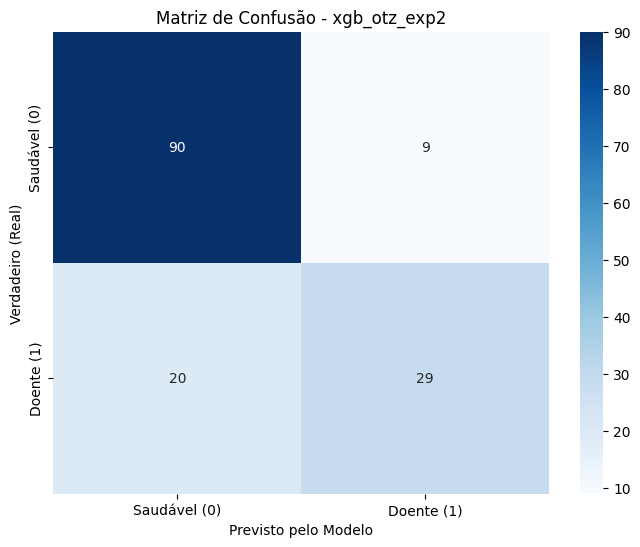

In [56]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'xgb_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'xgb_otz_exp2', caminho)